# Massive processing with atoms

The numpy/scipy style of the previous notebook works while the data fits in
memory. Past that you have to process in chunks, and chunking naively is
wrong: a filter that restarts at every chunk boundary leaves a transient at
each seam, so the answer depends on how you happened to cut the data.

An **atom** is a processing step that knows how to carry its state across
that seam. Every function you met in the previous notebook has one behind it.

In [1]:
import numpy as np

import xdas as xd
import xdas.atoms as xa

## From a workflow to a pipeline

Say you tried this on a small window and liked the result:

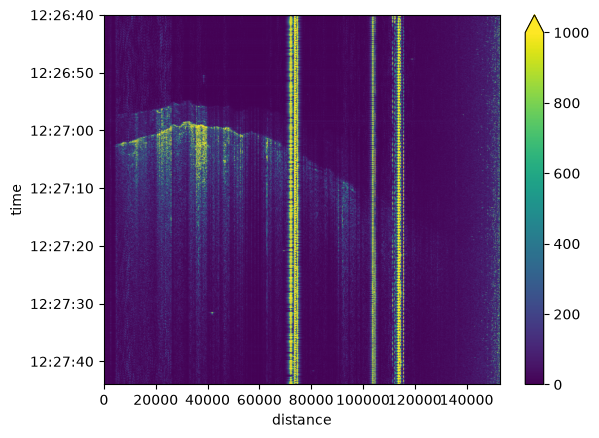

In [2]:
da = xd.open("outputs/event.nc")

def process(da):
    da = xd.resample(da, interval=250, snap=True, dim="distance")
    da = xd.filter(da, (1.0, None), ftype="iir", order=4, dim="time")
    return np.abs(da)


monolithic = process(da)
monolithic.plot(yincrease=False, vmin=0, vmax=1e3, interpolation="antialiased")

To get the pipeline behind it, call the same functions with `...` in place of
the data. Each one then returns its atom instead of applying it, and `>>`
chains them:

In [3]:
pipeline = process(...)
pipeline

Sequential:
  0: Resample(interval=250, snap=True, dim='distance')
  1: Filter(freq=(1.0, None))
  2: absolute(...)

In [4]:
pipeline = (
    xd.resample(..., interval=250, snap=True, dim="distance") 
    >> xd.filter(..., (1.0, None), ftype="iir", order=4, dim="time")
    >> np.abs
)
pipeline

Sequential:
  0: Resample(interval=250, snap=True, dim='distance')
  1: Filter(freq=(1.0, None))
  2: absolute(...)

Note the last line: under the seed, an ordinary numpy call does not compute
anything, it appends itself to the pipeline. So the pipeline reads like the
function it replaces.

The result is a callable, and on a whole array it gives exactly what the
function gave:

In [5]:
atomic = pipeline(da)
assert atomic.equals(monolithic)

## Running it chunk by chunk

`process` runs the same pipeline over a source it cuts into chunks. Here the
array is cut every 1000 samples along time:

In [6]:
chunked = pipeline.process(da, chunks={"time": 1000})
assert chunked.equals(monolithic)

  0%|          | 0.00/76.3M [00:00<?, ?B/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 119MB/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 119MB/s, read=9.7%, proc=90.3%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 126MB/s, read=9.7%, proc=90.3%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 126MB/s, read=0.7%, proc=99.3%, write=0.0%]

...

 75%|███████▌  | 57.2M/76.3M [00:00<00:00, 128MB/s, read=0.7%, proc=99.3%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 130MB/s, read=0.7%, proc=99.3%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 130MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 130MB/s, read=3.0%, proc=97.0%, write=0.0%] 

100%|██████████| 76.3M/76.3M [00:00<00:00, 128MB/s, read=3.0%, proc=97.0%, write=0.0%]

Bit for bit the same result — that is the property the whole design is for.
The highpass above is recursive: it *does* depend on the history of the
signal, and it is only identical because the atom carried its state from one
chunk to the next. At a genuine gap, where there is no history to carry, it
is flushed and restarted instead.

You can assert that property on a pipeline of your own, including across
gaps:

In [7]:
xd.testing.assert_chunk_invariant(pipeline, da, chunks={"time": 1000})

## Sources and sinks

`process` infers both ends. The source can be an array, a path or a glob, a
collection, a directory being watched, or a ZeroMQ address; the sink is
chosen from `out`: nothing for a result in memory, a directory to stream data
arrays to disk, a `.csv` for a table, an address to publish.

So the pipeline you just tested applies to the whole archive by changing the
two ends and nothing else:

In [8]:
%rm -rf outputs/chunks

In [9]:
chunked = pipeline.process(da, out="outputs/chunks", chunks={"time": 1000})
chunked

  0%|          | 0.00/76.3M [00:00<?, ?B/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 115MB/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:00, 115MB/s, read=10.4%, proc=88.3%, write=1.3%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 119MB/s, read=10.4%, proc=88.3%, write=1.3%]

 50%|█████     | 38.1M/76.3M [00:00<00:00, 119MB/s, read=1.8%, proc=98.2%, write=0.0%] 

...

100%|██████████| 76.3M/76.3M [00:00<00:00, 124MB/s, read=2.5%, proc=97.5%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 124MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:00<00:00, 124MB/s, read=3.9%, proc=95.7%, write=0.4%] 

100%|██████████| 76.3M/76.3M [00:00<00:00, 121MB/s, read=3.9%, proc=95.7%, write=0.4%]

<xdas.DataArray (time: 4000, distance: 625)>
VirtualStack: 19.1MB (float64)
Coordinates:
  * distance (distance): 0.000 to 152949.917
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:43.992

The directory holds one file per chunk, and what comes back is a single
virtual array over all of them:

In [10]:
%ls outputs/chunks

000000000  000000001  000000002  000000003


In [11]:
assert chunked.equals(monolithic)

```{note}
Asking for a result in memory that would not fit is refused rather than
attempted: `process` checks the accumulated size against the
`"memory_limit"` configuration entry, a quarter of the machine's memory by
default.
```

## Writing your own atoms

Everything so far was assembled from atoms that ship with Xdas. Writing your
own comes down to a single question: what does the step have to remember at a
chunk boundary, and where do you put it so that the machinery carries it for
you.

One example answers it three times: **STA/LTA**, the ratio of a short-term to
a long-term average of the signal energy. It is the oldest detector in
seismology and still the one you reach for to find out where, in hours of
record, something happened.

### A function is already an atom

Any callable taking one data array and returning one is accepted wherever an
atom is:

In [12]:
import scipy.signal as sp


def moving_average(power, size, axis):
    shape = tuple(size if a == axis else 1 for a in range(power.ndim))
    return sp.fftconvolve(power, np.ones(shape) / size, mode="same", axes=axis)


def sta_lta(da, sta=0.2, lta=5.0, dim="time"):
    """Short-term over long-term average of the signal energy."""
    axis = da.get_axis_num(dim)
    delta = xd.get_sampling_interval(da, dim)
    power = np.square(da.values.astype("float"))
    short = moving_average(power, round(sta / delta), axis)
    long = moving_average(power, round(lta / delta), axis)
    return da.copy(data=short / long)


xd.filter(..., (1.0, None), ftype="iir", order=4, dim="time") >> sta_lta

Sequential:
  0: Filter(freq=(1.0, None))
  1: sta_lta(...)

It shows up in the listing as `sta_lta(...)`: `>>` wrapped it into a
`Partial`, the atom that holds a function together with its fixed arguments —
`xa.Partial(sta_lta, lta=10.0)` when the defaults are not what you want.
`atomized` goes one step further and gives your own function the dual life the
Xdas ones have: called with data it computes, called with `...` it hands back
its atom.

In [13]:
sta_lta = xa.atomized(sta_lta)
sta_lta(..., lta=10.0) >> np.log10

Sequential:
  0: sta_lta(..., lta=10.0)
  1: log10(...)

### Where a plain function stops working

A function is handed each chunk on its own with nothing carried across the
seam, so wrapping one is only honest when the answer for a sample depends on
that sample alone: arithmetic, unit conversions, thresholds. Both averages
here look at the neighbours — the long one at five seconds of them — so the
invariance check refuses it rather than letting it through:

In [14]:
try:
    xd.testing.assert_chunk_invariant(sta_lta(...), da, chunks={"time": 1000})
except AssertionError as error:
    print(error)


Not equal to tolerance rtol=1e-07, atol=0
result
Mismatched elements: 9329428 / 40000000 (23.3%)
First 5 mismatches are at indices:
 [845, 0]: 0.12293440070013978 (ACTUAL), 0.12278864650376689 (DESIRED)
 [845, 1]: 0.12470084534928835 (ACTUAL), 0.12455173876630218 (DESIRED)
 [845, 2]: 0.00042618649244757637 (ACTUAL), 0.00042618642926148123 (DESIRED)
 [845, 3]: 0.15247348153570778 (ACTUAL), 0.15245695763317849 (DESIRED)
 [845, 4]: 0.5397973158038887 (ACTUAL), 0.5388286290923916 (DESIRED)
Max absolute difference among violations: 24.0368439
Max relative difference among violations: 3508.41700542
 ACTUAL: array([[1.817423, 1.81746 , 0.564998, ..., 0.362071, 0.426207, 0.475184],
       [2.797644, 2.800034, 0.564055, ..., 0.686671, 0.42513 , 1.946935],
       [4.251933, 4.253563, 0.57067 , ..., 0.702234, 0.899224, 2.736234],...
 DESIRED: array([[1.817423, 1.81746 , 0.564998, ..., 0.362071, 0.426207, 0.475184],
       [2.797644, 2.800034, 0.564055, ..., 0.686671, 0.42513 , 1.946935],
       

Nearly a quarter of the samples disagree. Every seam restarts both averages
from nothing, so each one spoils the whole long window that follows it — and
where the seams fall is a property of how you cut the stream, not of the data.

### Carrying a state through a function

The fix is not necessarily a class. When the state is a value the function can
take in and hand back — the `zi` of a SciPy filter being the archetype — a
function is still enough. Declare that state as a keyword argument passed
`...`, return it as an extra output, and `Partial` keeps it and feeds it back
at the next chunk. The function must accept `...` for it: that is how the
first chunk of a run says "no history yet".

That convolution, run left to right instead of all at once, is exactly a
filter — and all it has to remember at a chunk boundary is the samples still
inside its window, which is what `lfilter` carries in its `zi`. Two windows,
two states, two extra outputs:

In [15]:
def sta_lta(da, sta=0.2, lta=5.0, dim="time", zi_sta=..., zi_lta=...):
    """Short-term over long-term average, both windows trailing."""
    axis = da.get_axis_num(dim)
    delta = xd.get_sampling_interval(da, dim)
    power = np.square(da.values.astype("float"))
    averages = []
    for wlen, zi in [(sta, zi_sta), (lta, zi_lta)]:
        size = max(round(wlen / delta), 1)
        if zi is ...:
            shape = tuple(size - 1 if a == axis else n for a, n in enumerate(da.shape))
            zi = np.zeros(shape)
        averages.append(
            sp.lfilter(np.full(size, 1 / size), [1.0], power, axis=axis, zi=zi)
        )
    (short, zf_sta), (long, zf_lta) = averages
    return da.copy(data=short / long), zf_sta, zf_lta


atom = xa.Partial(sta_lta, sta=0.2, lta=5.0, dim="time", zi_sta=..., zi_lta=...)
atom

sta_lta(..., sta=0.2, lta=5.0, dim='time') [stateful]

The listing marks it `[stateful]`, and `atom.state` is where the two carried
values live between two chunks. It passes the check the first version
failed:

In [16]:
xd.testing.assert_chunk_invariant(atom, da, chunks={"time": 1000})

/tmp/ipykernel_158271/1206404796.py:16: RuntimeWarning: invalid value encountered in divide
  return da.copy(data=short / long), zf_sta, zf_lta


### Writing an Atom class

The warning that came out of that check is the honest verdict on the version
above. At the first samples of a run both averages are still filling up, and
the ratio they give is meaningless — where the record starts on silence,
literally `0/0`. A real detector does not report those samples at all, and
*not reporting* is exactly what a function cannot do: it is handed a chunk and
must answer with one, whereas an atom may answer with none, with one, or with
several.

That, together with state that has to be *designed from the data* — window
lengths in samples depend on a sampling rate you only meet at the first chunk
— is what subclassing `Atom` is for. It is two methods, plus a third as soon
as you buffer:

- `initialize(da, chunk_dim=None, **flags)` sees the first chunk of a run:
  derive whatever depends on the sampling rate, and allocate the state.
- `call(da, **flags)` processes one chunk and returns none, one, or several
  output chunks.
- `flush()` is called at the end of a run and at every seam, and returns what
  only became emittable because the stream ended. The atom below holds no
  sample back, so it keeps the default no-op; `xd.trigger`, at the end of this
  section, is one that does not.

Whatever you assign as `State(value)` is state: carried from chunk to chunk,
reported by `.state`, wiped by `reset()`, written out by `save_state`.
Anything else you assign is configuration, and is what the repr shows.
`State(...)` is the uninitialised sentinel, and it is what tells the machinery
that `initialize` still has to run. The `chunk_dim` flag names the dimension
the stream is being cut along, or is `None` for a single eager pass; an atom
that buffers uses it to switch its buffering off when there is no seam to
cross.

In [17]:
class STALTA(xa.Atom):
    """Short-term over long-term average, reported once the long one is warm."""

    def __init__(self, sta, lta, dim="time"):
        super().__init__()
        self.sta = sta  # configuration: the windows the user asked for
        self.lta = lta
        self.dim = dim
        self.nsta = xa.State(...)  # their lengths in samples, from the rate
        self.nlta = xa.State(...)
        self.zi = xa.State(...)  # what each average still has in its window
        self.count = xa.State(...)  # samples seen since the run started

    def initialize(self, da, chunk_dim=None, **flags):
        axis = da.get_axis_num(self.dim)
        delta = xd.get_sampling_interval(da, self.dim)
        self.nsta = xa.State(max(round(self.sta / delta), 1))
        self.nlta = xa.State(max(round(self.lta / delta), 1))
        self.zi = xa.State(
            [
                np.zeros(tuple(n - 1 if a == axis else s for a, s in enumerate(da.shape)))
                for n in (self.nsta, self.nlta)
            ]
        )
        self.count = xa.State(0)

    def call(self, da, **flags):
        axis = da.get_axis_num(self.dim)
        power = np.square(da.values.astype("float"))
        averages, zf = [], []
        for size, zi in zip((self.nsta, self.nlta), self.zi):
            values, state = sp.lfilter(
                np.full(size, 1 / size), [1.0], power, axis=axis, zi=zi
            )
            averages.append(values)
            zf.append(state)
        self.zi = xa.State(zf)
        cold = min(max(self.nlta - self.count, 0), da.sizes[self.dim])
        self.count = xa.State(self.count + da.sizes[self.dim])
        if cold == da.sizes[self.dim]:
            return None  # the long-term average has not warmed up yet
        warm = tuple(
            slice(cold, None) if a == axis else slice(None) for a in range(power.ndim)
        )
        return da.isel({self.dim: slice(cold, None)}).copy(
            data=averages[0][warm] / averages[1][warm]
        )

Nothing in `call` knows where the chunk boundaries are. It filters what it is
given, carries the two `zi`, and counts how far into the run it is so that the
first `lta` seconds are never reported — however the stream was cut, the
answer starts at the same sample:

In [18]:
atom = STALTA(0.2, 5.0, dim="time")
atom

STALTA(sta=0.2, lta=5.0)

In [19]:
atom(da)

<xdas.DataArray (time: 3688, distance: 10000)>
[[1.289887e+00 1.283983e+00 1.008340e-03 ... 1.417549e+00 1.457566e+00
  6.739882e-01]
 [1.079898e+00 1.075427e+00 8.452512e-04 ... 1.328326e+00 1.744419e+00
  6.668434e-01]
 [1.023524e+00 1.019083e+00 7.851632e-04 ... 1.079258e+00 1.440159e+00
  8.047960e-01]
 ...
 [4.397144e-01 4.404169e-01 1.681568e+00 ... 1.156686e+00 5.111613e-01
  6.755007e-01]
 [5.416695e-01 5.409342e-01 1.106543e+00 ... 1.268214e+00 4.630320e-01
  6.941619e-01]
 [6.582268e-01 6.565092e-01 1.111080e+00 ... 1.275005e+00 4.808050e-01
  7.675016e-01]]
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:26:45.000 to 2023-11-03T12:27:43.992
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

The record starts at 12:26:40 and the characteristic function at 12:26:45:
the five cold seconds are gone. A gap is a place where the long-term average
has to warm up again, but the atom does not have to know about it: at a seam
it is flushed and reset, and a new run starts on the far side. Declaring
`on_discontinuity = "raise"` on the class refuses discontinuous input instead
of restarting on it. `gaps=` puts that on trial, injecting discontinuities
that do not line up with the chunk boundaries, and chunks shorter than the
warm-up put the empty answer on trial too:

In [20]:
xd.testing.assert_chunk_invariant(atom, da, chunks={"time": 1000}, gaps=2)
xd.testing.assert_chunk_invariant(atom, da, chunks={"time": 200})

From there it is an ordinary atom: it composes with `>>`, it streams to any
of the sinks above, and `xa.atomized(STALTA)` hands back the `...`-seeded
function form if you want one.

  0%|          | 0.00/76.3M [00:00<?, ?B/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:02, 22.5MB/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:02, 22.5MB/s, read=1.8%, proc=98.2%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:01<00:01, 22.5MB/s, read=1.8%, proc=98.2%, write=0.0%]

 50%|█████     | 38.1M/76.3M [00:01<00:01, 22.5MB/s, read=0.1%, proc=99.9%, write=0.0%]

...

 75%|███████▌  | 57.2M/76.3M [00:02<00:00, 22.6MB/s, read=0.1%, proc=99.9%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:03<00:00, 22.7MB/s, read=0.1%, proc=99.9%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:03<00:00, 22.7MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 76.3M/76.3M [00:03<00:00, 22.7MB/s, read=0.5%, proc=99.5%, write=0.0%] 

100%|██████████| 76.3M/76.3M [00:03<00:00, 22.6MB/s, read=0.5%, proc=99.5%, write=0.0%]

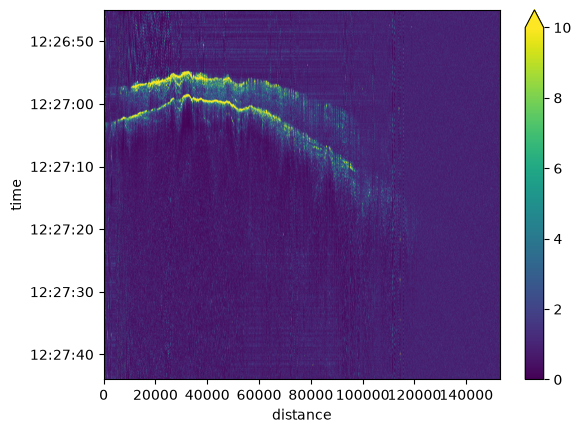

In [21]:
pipeline = xd.filter(
    ..., (1.0, None), ftype="iir", order=4, dim="time"
) >> STALTA(0.2, 5.0, dim="time")

cft = pipeline.process(da, chunks={"time": 1000})
cft.plot(yincrease=False, vmin=0, vmax=10, interpolation="antialiased")

Two curves stand out of the noise, and a threshold on them is a list of
detections. That last step ships as `xd.trigger`: a trigger still open when a
chunk ends is held back, which is the buffering case `flush` exists for.

In [22]:
detections = (pipeline >> xd.trigger(..., thresh=10.0)).process(
    da, chunks={"time": 1000}
)
detections

  0%|          | 0.00/76.3M [00:00<?, ?B/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:02, 21.7MB/s]

 25%|██▌       | 19.1M/76.3M [00:00<00:02, 21.7MB/s, read=1.4%, proc=98.3%, write=0.3%]

 50%|█████     | 38.1M/76.3M [00:01<00:01, 21.3MB/s, read=1.4%, proc=98.3%, write=0.3%]

 50%|█████     | 38.1M/76.3M [00:01<00:01, 21.3MB/s, read=0.1%, proc=99.8%, write=0.1%]

...

100%|██████████| 76.3M/76.3M [00:03<00:00, 21.7MB/s, read=0.1%, proc=99.8%, write=0.1%]

100%|██████████| 76.3M/76.3M [00:03<00:00, 21.7MB/s, read=0.0%, proc=99.9%, write=0.1%]

100%|██████████| 76.3M/76.3M [00:03<00:00, 21.7MB/s, read=0.4%, proc=99.5%, write=0.1%]

100%|██████████| 76.3M/76.3M [00:03<00:00, 21.6MB/s, read=0.4%, proc=99.5%, write=0.1%]

,distance,time,value
0,30.639006,2023-11-03 12:26:46.952,12.786729
1,30.639006,2023-11-03 12:26:51.640,12.851576
2,30.639006,2023-11-03 12:26:52.712,16.427125
3,45.958509,2023-11-03 12:26:51.656,11.741551
4,45.958509,2023-11-03 12:26:52.712,15.161648
...,...,...,...
8549,114497.964388,2023-11-03 12:27:39.832,21.848762
8550,114497.964388,2023-11-03 12:27:40.856,10.101411
8551,114513.283891,2023-11-03 12:27:39.768,18.904843
8552,5913.328105,2023-11-03 12:27:43.720,11.976874


```{note}
For realtime, `save_state` and `load_state` write the carried state to disk
and read it back, so that a restarted process picks up where the previous one
stopped instead of warming up again. Splitting the state that can be
recomputed into `initialize_from_state` keeps what has to be saved down to
the minimum.
```

## Picking phases on a large dataset

Machine-learning pickers are the same kind of problem — a model that wants
fixed-length windows, applied to something far longer. `xd.pick` wraps the
whole chain: it reads the weight set to find the rate the model expects,
resamples to it, runs the model with the window overlap and blinding it
declares, and triggers on the resulting probabilities.

In [23]:
from seisbench.models import PhaseNet

model = PhaseNet.from_pretrained("diting")
model.labels  # noise, P, S

'NPS'

In [24]:
da = xd.open("outputs/singlecable.nc")
da

<xdas.DataArray (time: 37500, distance: 10000)>
VirtualSource: 715.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984
    latitude (distance): [nan ... nan]
    longitude (distance): [nan ... nan]

The threshold is given per phase, which is also how the noise class gets
dropped — it is simply never asked for. Select phases by *name*: the label
order differs from one weight set to the next, so a position would be a bug
waiting to happen.

For a real archive, the same thing in atom form, streaming its table straight
to a CSV file:

In [25]:
%rm -f outputs/picks.csv

In [26]:
pipeline = (
    xd.resample(..., interval=500, snap=True, dim="distance")
    >> xd.pick(..., model, thresh={"P": 0.3, "S": 0.3}, device="cpu", dim="time")
)

In [27]:
picks = pipeline.process(da, out="outputs/picks.csv", chunks={"time": 3750})

  0%|          | 0.00/715M [00:00<?, ?B/s]

 10%|█         | 71.5M/715M [00:00<00:02, 263MB/s]

 10%|█         | 71.5M/715M [00:00<00:02, 263MB/s, read=10.9%, proc=89.1%, write=0.0%]

 20%|██        | 143M/715M [00:03<00:14, 41.0MB/s, read=10.9%, proc=89.1%, write=0.0%]

 20%|██        | 143M/715M [00:03<00:14, 41.0MB/s, read=0.1%, proc=99.8%, write=0.1%] 

...

 90%|█████████ | 644M/715M [00:23<00:02, 26.2MB/s, read=0.0%, proc=99.9%, write=0.0%]

100%|██████████| 715M/715M [00:26<00:00, 26.1MB/s, read=0.0%, proc=99.9%, write=0.0%]

100%|██████████| 715M/715M [00:26<00:00, 26.1MB/s, read=0.0%, proc=100.0%, write=0.0%]

100%|██████████| 715M/715M [00:27<00:00, 26.1MB/s, read=0.2%, proc=99.8%, write=0.0%] 

100%|██████████| 715M/715M [00:27<00:00, 26.9MB/s, read=0.2%, proc=99.8%, write=0.0%]

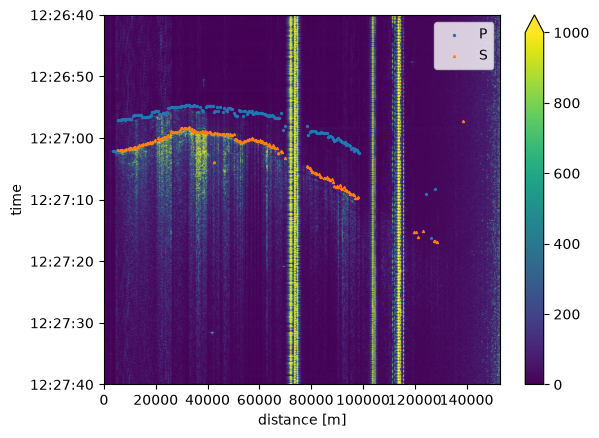

In [28]:
import matplotlib.pyplot as plt

monolithic.plot(vmin=0, vmax=1e3, interpolation="antialiased")

for phase, marker in [("P", "o"), ("S", "^")]:
    sub = picks[picks["phase"] == phase]
    plt.scatter(sub["distance"], sub["time"], s=2, marker=marker, label=phase)

plt.legend()
plt.ylim(np.datetime64("2023-11-03T12:27:40"), np.datetime64("2023-11-03T12:26:40"))
plt.xlabel("distance [m]")
plt.ylabel("time")
plt.show()

Two moveouts, converging near 40 km along the cable: the P and S arrivals of
a regional earthquake. The next notebook turns them into a located event.